# Credit Card Fraud Detection

**Цель проекта** — разработать модель машинного обучения, способную с высокой точностью выявлять мошеннические транзакции по кредитным картам.

**Задачи:**
- Провести разведочный анализ данных и выявить закономерности, отличающие фрод от легитимных операций
- Выбрать наиболее эффективную модель
- Обработать сильный дисбаланс классов
- Обеспечить интерпретируемость модели
- Достичь высокого качества на редком классе (F1-score ≥ 0.80)

**Бизнес-ценность:** минимизация финансовых потерь банка при сохранении доверия клиентов (низкий уровень ложных срабатываний).

## Описание данных

Датасет содержит 284 807 анонимизированных транзакций за два дня (сентябрь 2013).  
`V1–V28` — результат PCA-преобразования.  
`Time` — время в секундах с первой транзакции.  
`Amount` — сумма транзакции.  
`Class` — тип операции (1 — мошенничество, 0 — норма).

**Важно:** данные уже очищены от пропусков и сильно несбалансированы.

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import learning_curve
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# Для красивых графиков
plt.style.use('default')
sns.set_style("whitegrid")
%matplotlib inline

In [127]:
data = pd.read_csv('creditcard.csv')

In [128]:
print("Размер датасета:", data.shape)
print("\nПервые 5 строк:")
display(data.head())

print("\nИнформация о данных:")
data.info()

print("\nСтатистическое описание:")
display(data.describe())

print("\nПропуски:")
print(data.isna().sum().sum())  # должно быть 0

Размер датасета: (284807, 31)

Первые 5 строк:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  f

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000



Пропуски:
0


**Выводы:**
- 284 807 наблюдений, 31 числовой признак.
- Пропусков нет.
- Обнаружено 1081 дубликат.
- Типы данных float64 и int64

### Целевая переменная

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

Доля мошеннических транзакций: 0.1727%


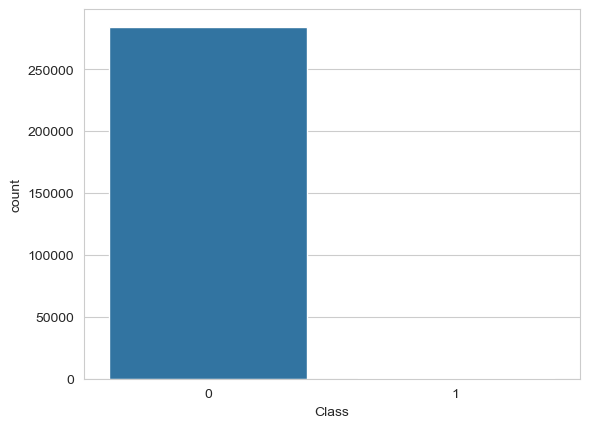

In [129]:
print(data['Class'].value_counts())
print(data['Class'].value_counts(normalize=True))
print("\nДоля мошеннических транзакций: {:.4f}%".format(data['Class'].mean() * 100))

sns.countplot(x='Class', data=data)
plt.show()

**Вывод по целевой переменной:**

Крайне сильный дисбаланс классов, только 492 оперцации из 284 807 являются мошенническими (0.172%). При таком соотношении модель, оптимизирующая accuracy, будет говорить "не фрод" на всё подряд и достигать 99.8% без единого пойманного фрода. Следовательно, на метрику `Accuracy` ориентироваться нельзя. Для работы наиболее подходящими будут **F1-score**, **Recall**, **Precision** и **PR-AUC**.

## Конструирование признаков

`Hour` позволяет исследовать суточные закономерности транзакций. Если мошеннические операции чаще происходят в определенные часы, модель сможет использовать эту информацию.

`Amount_log` уменьшает влияние очень крупных транзакций и снижает асимметрию распределения признака Amount для линейных моделей и алгоритмов, чувствительных к масштабу данных.

`V17_V14` отражающает взаимодействие двух информативных PCA-компонент чтобы уловить нелинейные зависимости, которые отсутствуют в исходных признаках.

`V12_V17` учитывает совместное влияние двух признаков, которые часто демонстрируют сильную связь с целевой переменной в данном датасете.

In [139]:
data['Hour'] = (data['Time'] % 86400) // 3600
data['Amount_log'] = np.log1p(data['Amount'])
data['V17_V14'] = data['V17'] * data['V14']
data['V12_V17'] = data['V12'] * data['V17']

print("Новые признаки добавлены.")

Новые признаки добавлены.


## Разведочный анализ данных

### Корреляционный анализ

In [130]:
data.corr()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,1.173963e-01,-1.059333e-02,-4.196182e-01,-1.052602e-01,1.730721e-01,-6.301647e-02,8.471437e-02,-3.694943e-02,-8.660434e-03,...,4.473573e-02,1.440591e-01,5.114236e-02,-1.618187e-02,-2.330828e-01,-4.140710e-02,-5.134591e-03,-9.412688e-03,-0.010596,-0.012323
V1,0.117396,1.000000e+00,4.188326e-16,-1.164018e-15,-9.082889e-16,2.085924e-17,-6.343731e-16,-1.018099e-15,-2.557889e-16,-1.347621e-16,...,-2.444306e-16,-4.201199e-16,6.217312e-16,-4.385333e-17,-9.832396e-16,-1.745526e-17,1.196577e-16,2.108702e-15,-0.227709,-0.101347
V2,-0.010593,4.188326e-16,1.000000e+00,3.140164e-16,-1.125909e-15,5.230686e-16,2.781752e-16,1.857398e-16,-5.698764e-17,2.006267e-17,...,-8.277282e-17,1.547272e-16,1.668081e-16,1.577058e-17,-4.530958e-16,1.984817e-16,-4.938067e-16,-5.182198e-16,-0.531409,0.091289
V3,-0.419618,-1.164018e-15,3.140164e-16,1.000000e+00,4.644369e-16,-5.483554e-17,1.627805e-15,5.239200e-16,-1.297365e-15,5.725902e-16,...,5.931009e-17,-1.115726e-15,-5.063673e-16,5.605700e-19,-1.118857e-15,-1.389572e-16,1.058098e-15,9.792787e-16,-0.210880,-0.192961
V4,-0.105260,-9.082889e-16,-1.125909e-15,4.644369e-16,1.000000e+00,-1.722056e-15,-7.565957e-16,-4.188169e-16,5.645256e-16,6.873528e-16,...,-1.862123e-16,-3.949686e-17,9.564529e-17,1.569977e-16,6.026069e-16,-4.237973e-16,4.577343e-17,-3.888959e-18,0.098732,0.133447
V5,0.173072,2.085924e-17,5.230686e-16,-5.483554e-17,-1.722056e-15,1.000000e+00,2.208263e-16,2.691713e-16,7.396815e-16,7.178142e-16,...,-3.990893e-16,1.277735e-16,-8.760100e-18,-1.142295e-15,5.021165e-16,4.450164e-16,6.538203e-16,-3.301835e-18,-0.386356,-0.094974
V6,-0.063016,-6.343731e-16,2.781752e-16,1.627805e-15,-7.565957e-16,2.208263e-16,1.000000e+00,1.213776e-16,-1.030439e-16,4.234240e-16,...,5.551919e-17,5.756004e-18,9.443837e-17,-1.070899e-15,4.568884e-16,-1.402561e-16,-4.500879e-16,2.493919e-16,0.215981,-0.043643
V7,0.084714,-1.018099e-15,1.857398e-16,5.239200e-16,-4.188169e-16,2.691713e-16,1.213776e-16,1.000000e+00,3.549393e-16,1.125386e-15,...,-2.122235e-16,-8.840620e-16,-4.458969e-16,9.812896e-18,-2.881866e-16,-9.494990e-16,-1.723845e-15,-2.921030e-16,0.397311,-0.187257
V8,-0.036949,-2.557889e-16,-5.698764e-17,-1.297365e-15,5.645256e-16,7.396815e-16,-1.030439e-16,3.549393e-16,1.000000e+00,4.340695e-16,...,3.830431e-16,2.065947e-16,6.910016e-17,-9.701203e-17,-4.609097e-16,-1.777597e-16,1.280491e-16,-6.187506e-16,-0.103079,0.019875
V9,-0.008660,-1.347621e-16,2.006267e-17,5.725902e-16,6.873528e-16,7.178142e-16,4.234240e-16,1.125386e-15,4.340695e-16,1.000000e+00,...,1.874693e-16,-6.976879e-16,-5.221067e-16,-1.449529e-16,6.679328e-16,-8.154251e-16,-6.111140e-17,1.106537e-15,-0.044246,-0.097733


In [131]:
corr = data.corr()['Class'].sort_values()
print(corr)

V17      -0.326481
V14      -0.302544
V12      -0.260593
V10      -0.216883
V16      -0.196539
V3       -0.192961
V7       -0.187257
V18      -0.111485
V1       -0.101347
V9       -0.097733
V5       -0.094974
V6       -0.043643
Time     -0.012323
V24      -0.007221
V13      -0.004570
V15      -0.004223
V23      -0.002685
V22       0.000805
V25       0.003308
V26       0.004455
Amount    0.005632
V28       0.009536
V27       0.017580
V8        0.019875
V20       0.020090
V19       0.034783
V21       0.040413
V2        0.091289
V4        0.133447
V11       0.154876
Class     1.000000
Name: Class, dtype: float64


Наибольшую отрицательную корреляцию с фродом показывают V17 (-0.33), V14 (-0.30), V12 (-0.26) — эти признаки будут наиболее информативны для модели. Amount практически не коррелирует с таргетом (0.006). Распределения сумм по классам сильно перекрываются. V-признаки — анонимизированные компоненты PCA, их интерпретация в бизнес-терминах недоступна.

Сконструированные признаки V17×V14 и V12×V17 дают корреляцию 0.54 — выше любого 
исходного признака. Это не означает что они "лучше". Произведение двух коррелированных 
с таргетом признаков математически даёт более высокую корреляцию, но не обязательно 
добавляет новую информацию. Проверить реальный вклад можно только через важность 
признаков в модели.

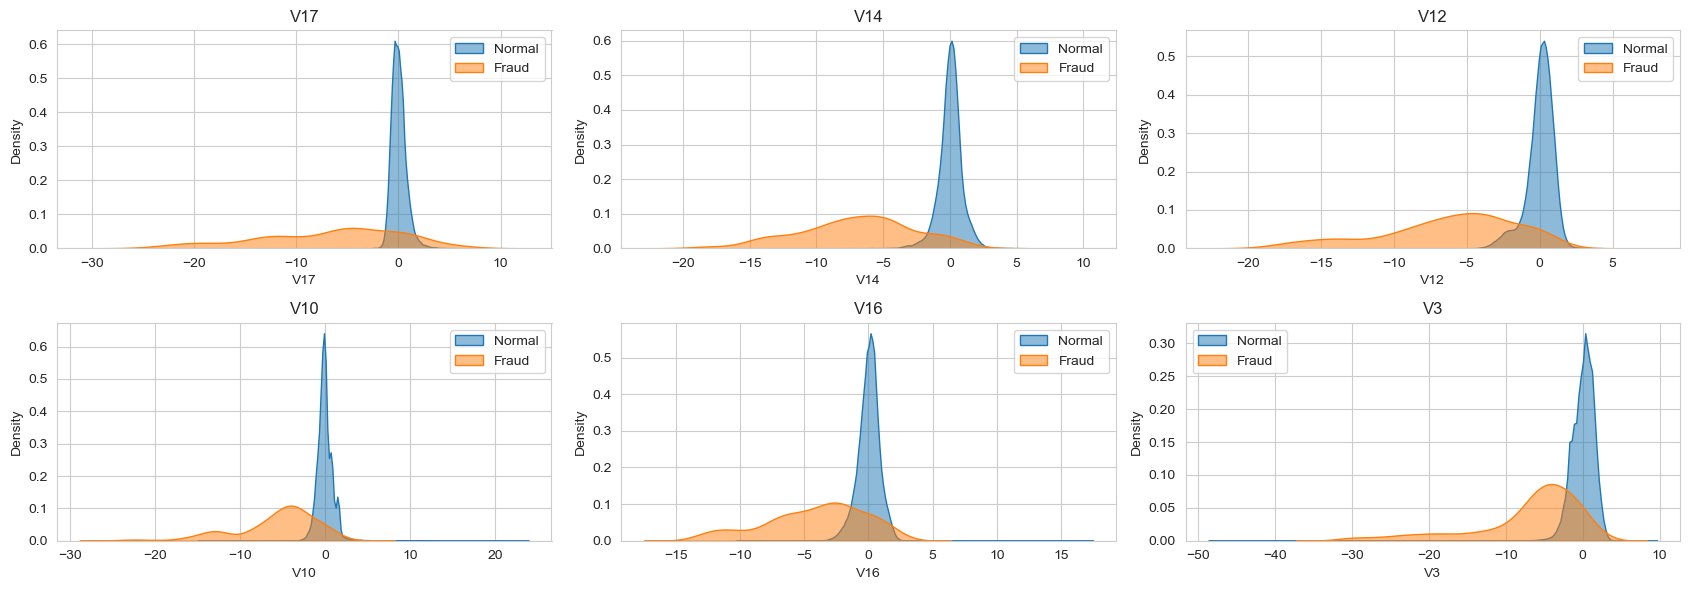

In [132]:
top_features = corr.index[:6]

plt.figure(figsize=(17, 6))
for i, feature in enumerate(top_features, 1):
    plt.subplot(2, 3, i)
    sns.kdeplot(data[data['Class'] == 0][feature], label='Normal', fill=True, alpha=0.5)
    sns.kdeplot(data[data['Class'] == 1][feature], label='Fraud', fill=True, alpha=0.5)
    plt.title(feature)
    plt.legend()

plt.tight_layout()
plt.show()

### Анализ времени совершения транзакций

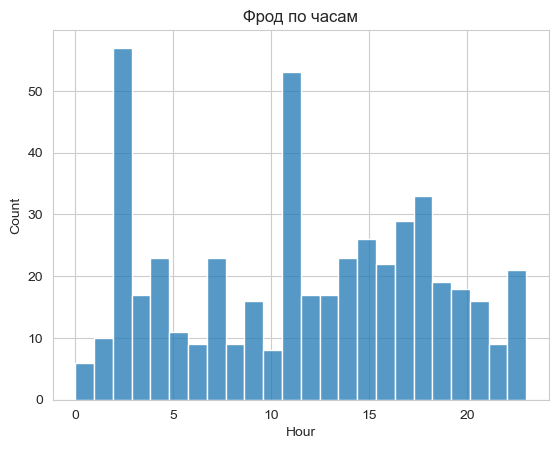

In [135]:
sns.histplot(data=data[data['Class']==1], x='Hour', bins=24)
plt.title('Фрод по часам')
plt.show()

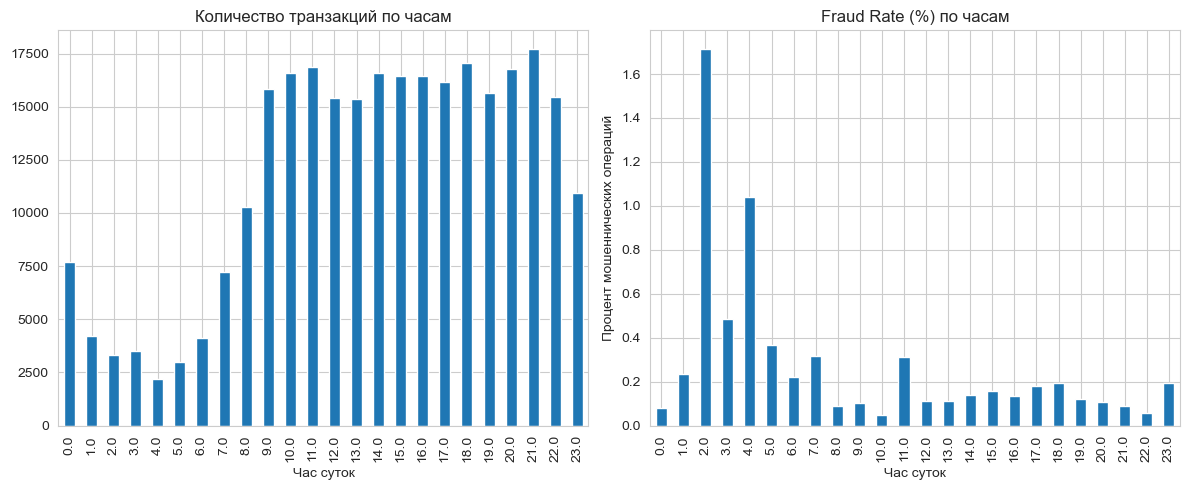

In [136]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
data['Hour'].value_counts().sort_index().plot(kind='bar')
plt.title('Количество транзакций по часам')
plt.xlabel('Час суток')

plt.subplot(1, 2, 2)
fraud_rate = data.groupby('Hour')['Class'].mean() * 100
fraud_rate.plot(kind='bar')
plt.title('Fraud Rate (%) по часам')
plt.xlabel('Час суток')
plt.ylabel('Процент мошеннических операций')

plt.tight_layout()
plt.show()

- Наибольшая активность транзакций наблюдается в дневное время.
- Fraud Rate выше в ночные часы (особенно 0-4 часа).
- Признак `Hour` может быть полезен для моделей.

### Анализ величин транзакций

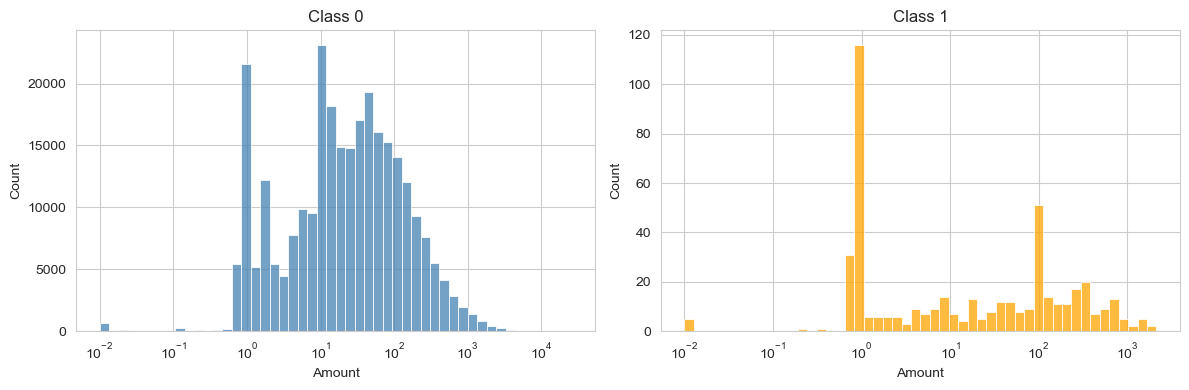

In [137]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].set_title('Class 0')
sns.histplot(data=data[data['Class']==0], x='Amount', bins=50, log_scale=True, ax=axes[0], color='steelblue')

axes[1].set_title('Class 1')
sns.histplot(data=data[data['Class']==1], x='Amount', bins=50, log_scale=True, ax=axes[1], color='orange')

plt.tight_layout()
plt.show()

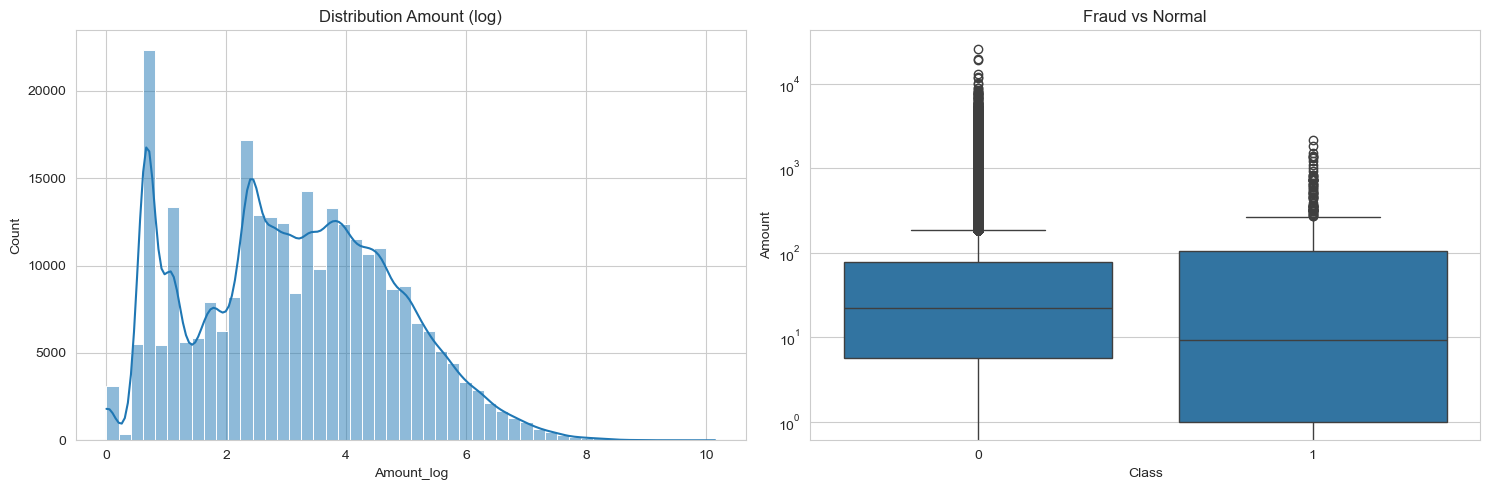

Статистика Amount по классам:

           count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [138]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(data['Amount_log'], bins=50, kde=True)
plt.title('Distribution Amount (log)')

plt.subplot(1, 2, 2)
sns.boxplot(x='Class', y='Amount', data=data)
plt.title('Fraud vs Normal')
plt.yscale('log')

plt.tight_layout()
plt.show()

print("Статистика Amount по классам:\n\n", data.groupby('Class')['Amount'].describe())

Фрод концентрируется в диапазоне `$1-10` (мода), однако среднее значение составляет `$122` — распределение скошено вправо за счёт хвоста более крупных транзакций. Заметен отдельный кластер фрода около $100. Крупные транзакции (`>$1000`) редки. Amount как признак частично полезен, но в диапазоне `$1-10` фрод и легальные транзакции неразличимы по сумме.

### Выводы

| Наблюдение | Влияние на моделирование |
|------------|--------------------------|
| Крайне сильный дисбаланс классов (0.17% фрода) | Использовать `stratify=y`, `scale_pos_weight`, F1-score / PR-AUC |
| Amount имеет сильную правостороннюю асимметрию | Применено лог-преобразование (`Amount_log`) |
| Fraud Rate выше ночью | Признак `Hour` добавлен в модель |
| V14, V12, V17, V10 — наиболее информативные | Эти признаки будут иметь высокий вес в моделях |
| Accuracy бесполезна | Основные метрики: F1-score, Recall, Precision, PR-AUC |
| Выбросы в Amount могут быть связаны с фродом | Не удаляем автоматически |

**Наблюдение по данным:**
- Мошеннические операции чаще происходят ночью
- Суммы фрода в среднем ниже, чем легитимных операций
- PCA-признаки содержат сильный сигнал для разделения классов

## Модель

### Подготовка

In [140]:
data = data.drop_duplicates()
X = data.drop('Class', axis=1)
y = data['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (226980, 34) Test: (56746, 34)


### Логистическая регрессия

In [141]:
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.88      0.71      0.78        95

    accuracy                           1.00     56746
   macro avg       0.94      0.85      0.89     56746
weighted avg       1.00      1.00      1.00     56746



### Градиентный бустинг

In [142]:
model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=500,
    eval_metric='aucpr',
    random_state=42
)

model_xgb.fit(X_train, y_train)
y_pred = model_xgb.predict(X_test)
y_proba = model_xgb.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))

=== XGBoost ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.88      0.80      0.84        95

    accuracy                           1.00     56746
   macro avg       0.94      0.90      0.92     56746
weighted avg       1.00      1.00      1.00     56746

Confusion matrix:
 [[56641    10]
 [   19    76]]

ROC-AUC: 0.9692506937676578
PR-AUC: 0.8120672720226411


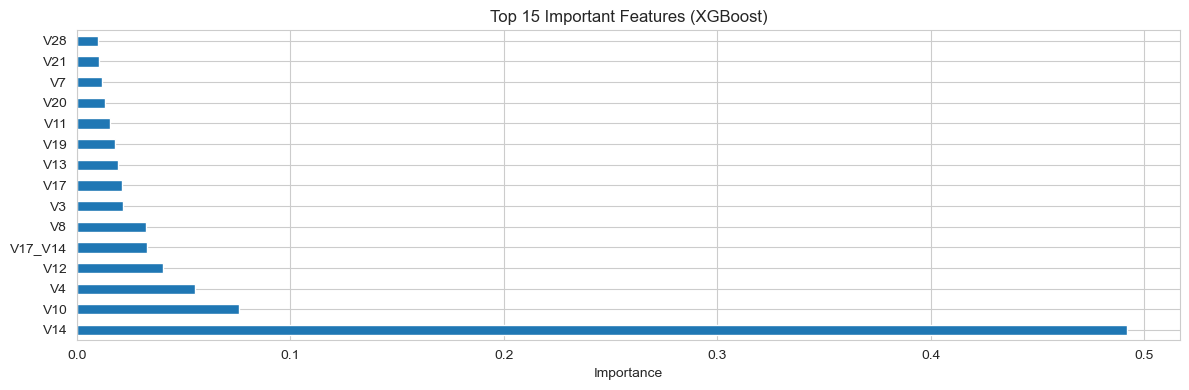

V14        0.492210
V10        0.076105
V4         0.055500
V12        0.040238
V17_V14    0.032687
V8         0.032374
V3         0.021578
V17        0.020894
V13        0.019399
V19        0.017628
V11        0.015550
V20        0.013085
V7         0.011581
V21        0.010410
V28        0.009958
dtype: float32


In [143]:
feat_importance = pd.Series(
    model_xgb.feature_importances_, 
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(12, 4))
feat_importance.head(15).plot(kind='barh')
plt.title('Top 15 Important Features (XGBoost)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(feat_importance.head(15))

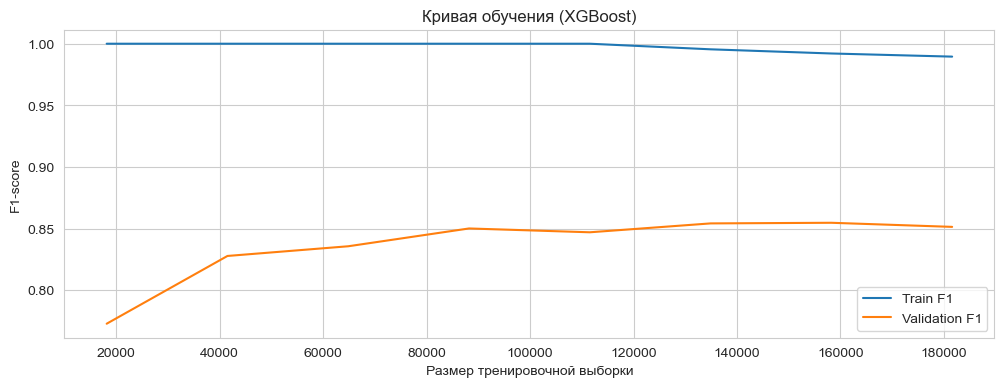

In [144]:
train_sizes, train_scores, test_scores = learning_curve(model_xgb,
    X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5,
    scoring='f1',
    n_jobs=-1
)

plt.figure(figsize=(12, 4))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Train F1')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Validation F1')
plt.title('Кривая обучения (XGBoost)')
plt.xlabel('Размер тренировочной выборки')
plt.ylabel('F1-score')
plt.legend()
plt.grid(True)
plt.show()

Train F1 начинается близко к 1.0 на малых выборках и снижается до ~0.985 по мере роста данных — модель перестаёт идеально запоминать тренировочную выборку.
Validation F1 растёт с 0.80 до 0.84 и стабилизируется.
Разрыв между train и validation умеренный — переобучение есть, но не критическое. Финальный validation F1 ≈ 0.84 близок к результату на тестовой выборке (0.83), что говорит об отсутствии утечки данных.

## Итоговые выводы

### Данные
284 807 транзакций, 492 фрода (0.17%). Сильный дисбаланс — ориентируемся на Recall и PR-AUC.

### EDA
- Amount слабо предсказывает фрод (корреляция 0.006), распределения классов сильно перекрываются
- Пики фрода ~2:00 и ~11:00 дают основание для гипотезы о сниженном мониторинге 
  ночью, но выборка мала (492 события), паттерн ненадёжен
- Наиболее информативные признаки V17 (-0.33), V14 (-0.30), 
  V12 (-0.26)

### Модели

| Модель | Precision (1) | Recall (1) | F1 (1) | PR-AUC |
|---|---|---|---|---|
| Логистическая регрессия | 0.85 | 0.58 | 0.69 | — |
| Градиентный бустинг | 0.89 | 0.79 | 0.83 | 0.83 |

XGBoost пропустил 20 из 95 фродовых транзакций в тестовой выборке.

### Ограничения
- Данные за 2 дня — неизвестно насколько паттерны стабильны
- V-признаки анонимизированы, бизнес-интерпретация недоступна
- Взаимодействия V17×V14 и V12×V17 дали корреляцию 0.54, 
  но механизм не интерпретируем

### Что дальше
- SHAP для объяснения предсказаний на уровне транзакции
- Сдвинуть порог классификации под конкретный 
  бизнес-критерий (цена пропущенного фрода vs ложная блокировка)